<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-03/trabalho-03/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Equipe**: 01<br>
> **Estudantes**: Cristina Siewert Jansen, Marlon Sbardelatti e Sofia Sousa Lindner

# PARTE 2: Algoritmo Árvores de Decisão

In [1]:
FEATURE_NAMES = ['historia', 'divida', 'garantia', 'renda']
CLASS_NAMES = ['alto', 'moderado', 'baixo']

Nesta segunda parte do Trabalho você irá aplicar os algoritmos de Árvore de Decisão e de Floresta Aleatória na base de dados de risco de crédito discutida em aula. Para isso você deve primeiramente importar as bibliotecas necessárias.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 1 - Importação dos dados Pré-Processados

a) importe o arquivo salvo como 'risco_credito.pkl'



In [3]:
import pickle
with open('risco_credito.pkl', 'rb') as f:
  X_risco_credito, y_risco_credito = pickle.load(f)

# 2 - Algoritmo de Árvore de Decisão



a) importar da biblioteca sklearn o pacote DecisionTreeClassifier

In [4]:
from sklearn.tree import DecisionTreeClassifier

b) Calcule a árvore de decisão, utilizando como critério a entropia.
Coloque como nome da variável: arvore_risco_credito

In [5]:
decision_tree_classifier = DecisionTreeClassifier(criterion='entropy')

arvore_risco_credito = decision_tree_classifier.fit(X_risco_credito, y_risco_credito)

c) Utilize o feature_importances_ para retornar a importância de cada atributo. Qual possui o maior ganho de informação?

In [6]:
for feature, importance in zip(FEATURE_NAMES, arvore_risco_credito.feature_importances_):
  print(f'{feature} -> {importance}')

historia -> 0.48015651164102663
divida -> 0.03885431480296544
garantia -> 0.03885431480296544
renda -> 0.4421348587530425


O atributo de maior importância é a renda (0.48).

d) Gere uma visualização da sua árvore de decisão utilizando o pacote tree da biblioteca do sklearn.

OBS: Adicione cores, nomes para os atributos e para as classes.

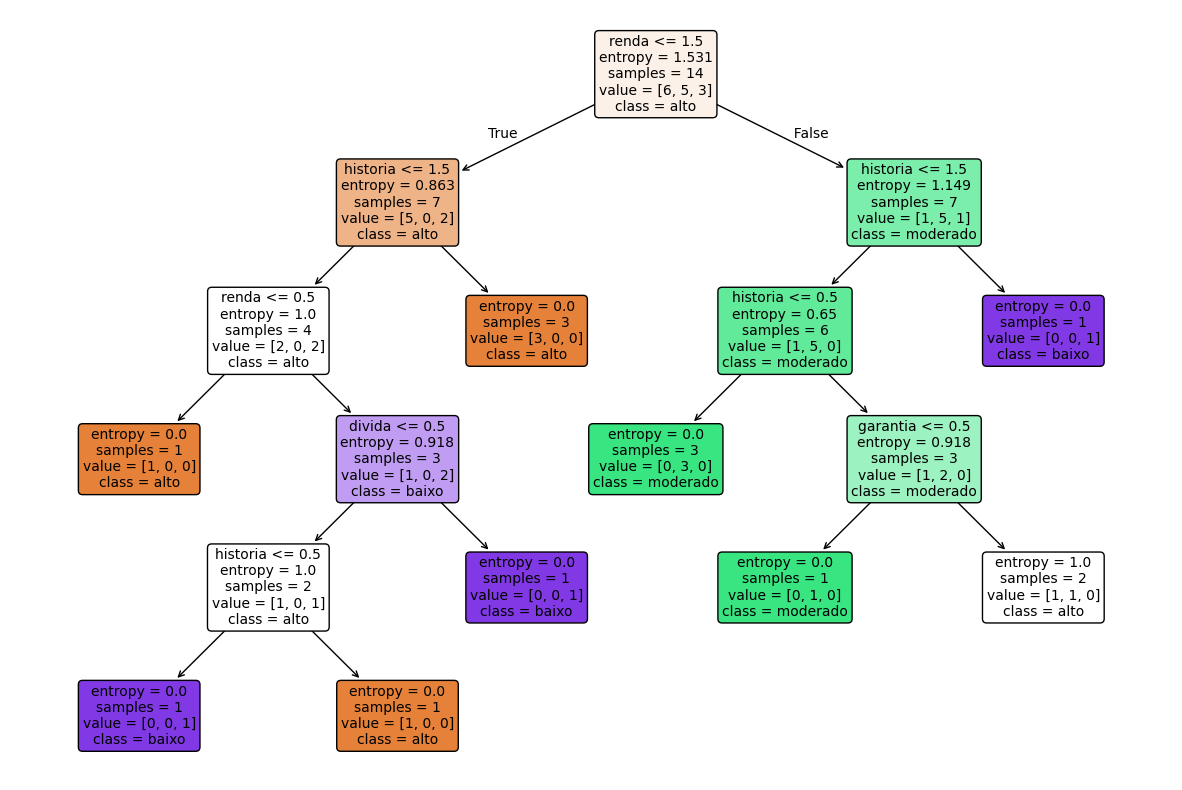

In [7]:
from sklearn import tree

plt.figure(figsize=(15,10))

tree.plot_tree(decision_tree=arvore_risco_credito,
               feature_names=FEATURE_NAMES,
               class_names=CLASS_NAMES,
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

e) FAZER A PREVISÃO

Utilize .predict para fazer a previsão realizada no exemplo em sala.

   i. história boa, dívida alta, garantia nenhuma, renda > 35

   ii. história ruim, dívida alta, garantia adequada, renda < 15


Verifique nos slides se seu resultado está correto!

In [8]:
# i. história boa, dívida alta, garantia nenhuma, renda > 35

# ii. história ruim, dívida alta, garantia adequada, renda < 15

predictions = arvore_risco_credito.predict([[0, 0, 0, 2],[2, 0, 1, 0]])

print(predictions) # Baixo, alto

[1 0]


#3 - Algoritmo de Árvore de Decisão para uma base de dados maior (Credit Data)

Nesta seção você deverá testar o uso da Árvore de Decisão para a Base de Dados Credit Risk Dataset. Aqui estaremos analisando os clientes que pagam (classe 0) ou não pagam a dívida (classe 1), a fim do banco conceder empréstimo.

In [9]:
ATTRIBUTE_NAMES = ['renda', 'idade', 'emprestimo']
TARGET_NAMES = ['paga', 'nao paga']

In [10]:
# abrir o arquivo
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

a) Ao abrir o arquivo utilize .shape para verificar o tamanho dos dados de treinamento e de teste

OBS: os dados de treinamento devem ter as seguintes dimensões: x=(1500, 3), y=(1500,); os dados de teste devem ter as seguintes dimensões: x=(500, 3), y=(500,)

In [11]:
X_credit_treinamento.shape, y_credit_treinamento.shape, X_credit_teste.shape, y_credit_teste.shape

((1500, 3), (1500,), (500, 3), (500,))

b) Importe o pacote DecisionTreeClassifier do sklearn para treinar o seu algoritmo de árvore de decisão. Para poder refazer os testes e obter o mesmo resultado utilize o parâmetro random_state = 0.

In [12]:
credit_risk_classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)

arvore_credit = credit_risk_classifier.fit(X_credit_treinamento, y_credit_treinamento)

c) Faça a previsão com os dados de teste. Visualize os dados e verifique se as previsões estão de acordo com os dados de teste (respostas reais).

In [13]:
predictions_credit_risk = arvore_credit.predict(X_credit_teste)

count_diff = 0
predictions_size = len(predictions_credit_risk)
for i in range(predictions_size):
  if predictions_credit_risk[i] != y_credit_teste[i]:
    count_diff += 1

print(f'Previsões corretas: {predictions_size-count_diff}/{predictions_size}')
print(f'Previsões incorretas: {count_diff}/{predictions_size}')

Previsões corretas: 491/500
Previsões incorretas: 9/500


d) Agora faça o cálculo da acurácia para calcular a taxa de acerto entre os valores reais (y teste) e as previsões

In [14]:
from sklearn.metrics import accuracy_score, classification_report

In [15]:
print(f'Acurácia: {accuracy_score(y_credit_teste, predictions_credit_risk)}')

Acurácia: 0.982


e) Faça a análise da Matriz de Confusão.

i. Quantos clientes foram classificados corretamente que pagam a dívida?

ii. Quantos clientes foram classificados incorretamente como não pagantes?

iii. Quantos clientes foram classificados corretamente que não pagam?

iv. Quantos clientes foram classificados incorretamente como pagantes?

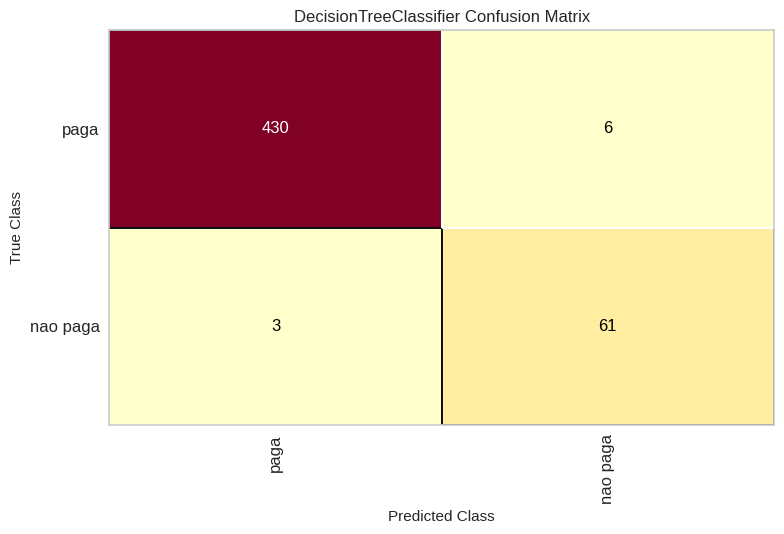

Clientes que pagam classificados corretamente: 430
Clientes classificados incorretamente como não pagantes: 6
Clientes que não pagam classificados corretamente: 61
Clientes classificados incorretamente como pagantes: 3


In [16]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(arvore_credit, classes=TARGET_NAMES)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)
cm.show()

# Acessar as células da matriz para apresentar os valores
cm_data = cm.confusion_matrix_

# i)
print(f'Clientes que pagam classificados corretamente: {cm_data[0][0]}')
# ii)
print(f'Clientes classificados incorretamente como não pagantes: {cm_data[0][1]}')
# iii)
print(f'Clientes que não pagam classificados corretamente: {cm_data[1][1]}')
# iv)
print(f'Clientes classificados incorretamente como pagantes: {cm_data[1][0]}')

f) Faça um print do parâmetro classification_report entre os dados de teste e as previsões. Explique qual é a relação entre precision e recall nos dados. Como você interpreta esses dados?

In [17]:
test_report = classification_report(y_credit_teste,
                                    predictions_credit_risk,
                                    target_names=TARGET_NAMES)

print(f'Relatório com métricas: \n{test_report}')

Relatório com métricas: 
              precision    recall  f1-score   support

        paga       0.99      0.99      0.99       436
    nao paga       0.91      0.95      0.93        64

    accuracy                           0.98       500
   macro avg       0.95      0.97      0.96       500
weighted avg       0.98      0.98      0.98       500



A análise da matriz de confusão através de métricas é muito útil para avaliar performance contextual em problemas de classificação binária.

A precisão avalia os exemplos corretamente classificados como positivos dentro das predições, sendo relevante quando se quer evitar falsos positivos. Já o recall mede a proporção de verdadeiros positivos corretamente classificados em relação aos positivos reais e é relevante quando se quer evitar falsos negativos.

Nessa situação, uma pessoa que não pagaria sendo classificada como pagante gera significativamente mais prejuízo do que uma pessoa que pagaria sendo classificada como não pagante - um falso negativo para a classe "nao paga". Isso significa que a métrica de recall para a classe "nao paga" é a métrica mais relevante.

Para a classe "paga", houve precisão e recall de 99%, ou seja, praticamente todos os clientes classificados como pagantes realmente pagam, e quase todos os pagantes reais foram corretamente identificados.

Para a classe "nao paga", o desempenho foi em geral mais baixo, indicando que 91% dos exemplos classificados como não pagantes realmente o são, e 95% de todos os não pagantes reais foram identificados.

g) Gere uma visualização da sua árvore de decisão utilizando o pacote tree da biblioteca do sklearn.

OBS 1: Os atributos previsores são = ['income', 'age', 'loan']

OBS 2: Adicione cores, nomes para os atributos e para as classes. Você pode utilizar a função fig.savefig para salvar a árvore em uma imagem .png

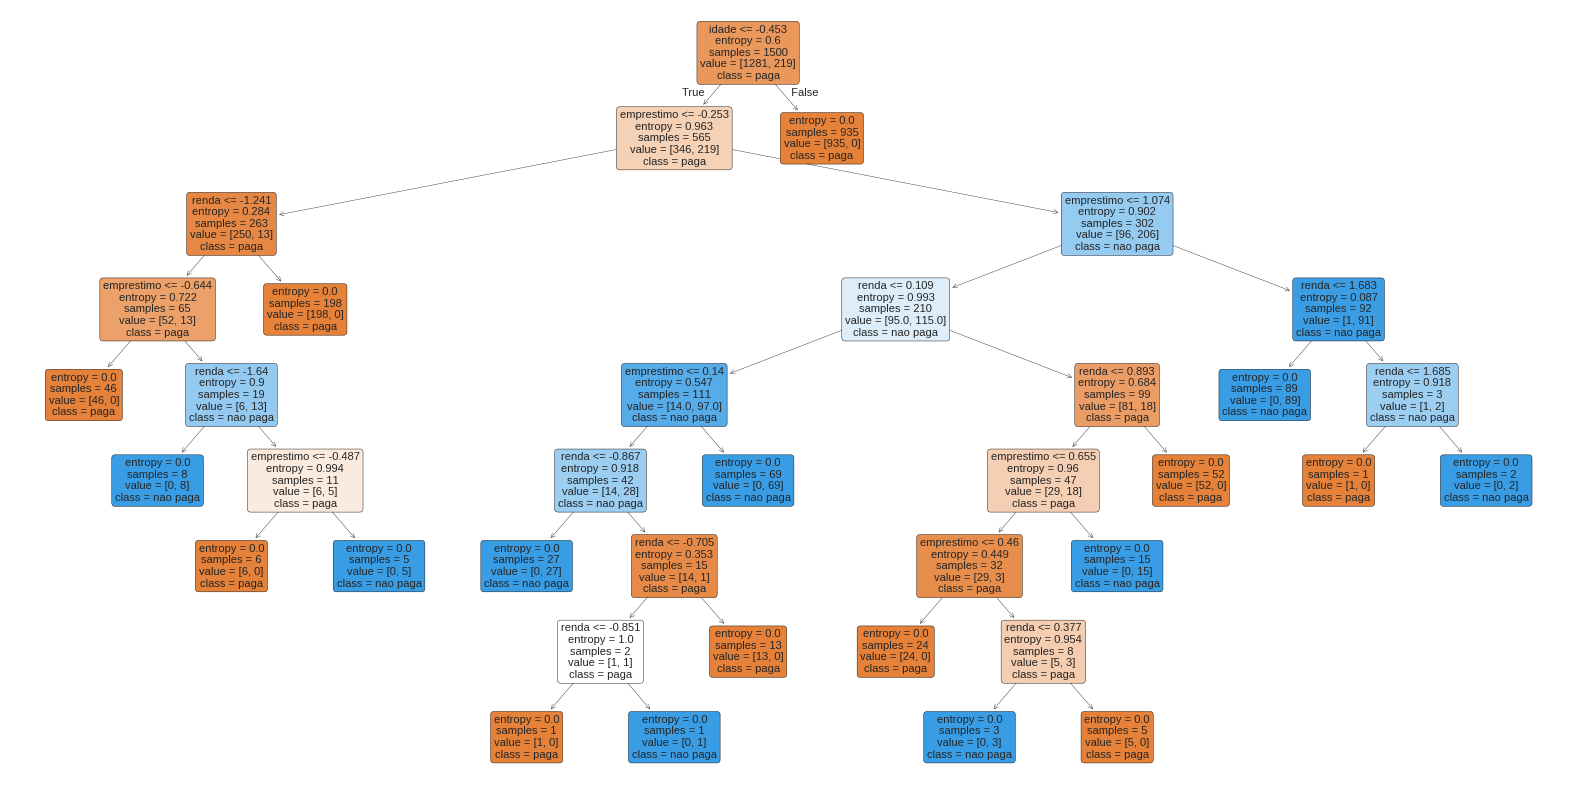

In [18]:
plt.figure(figsize=(20,10))

tree.plot_tree(decision_tree=arvore_credit,
               feature_names=ATTRIBUTE_NAMES,
               class_names=TARGET_NAMES,
               filled=True,
               rounded=True,
               fontsize=8)

plt.show()

# Algoritmo Random Forest

Nesta seção iremos utilizar o algoritmo Random Forest para a mesma base de crédito (**Credit Risk Dataset**) - arquivo *credit.pkl*.

a) Importe o pacote RandomForestClassifier do sklearn para treinar o seu algoritmo de floresta randomica.

In [19]:
from sklearn.ensemble import RandomForestClassifier

b) Para gerar a classificação você deve adicionar alguns parâmetros:
*   n_estimators=10  --> número de árvores que você irá criar
*   criterion='entropy'
*   random_state = 0

In [20]:
random_forest_classifier = RandomForestClassifier(n_estimators=10,
                                                   criterion='entropy',
                                                   random_state=0)

forest_credit = random_forest_classifier.fit(X_credit_treinamento, y_credit_treinamento)

c) Faça a previsão com os dados de teste. Visualize os dados e verifique se as previsões estão de acordo com os dados de teste (respostas reais).

In [21]:
predictions_credit_forest = forest_credit.predict(X_credit_teste)

count_diff = 0
predictions_size = len(predictions_credit_forest)
for i in range(predictions_size):
  if predictions_credit_forest[i] != y_credit_teste[i]:
    count_diff += 1

print(f'Previsões corretas:  {predictions_size-count_diff}/{predictions_size}')
print(f'Previsões incorretas: {count_diff}/{predictions_size}')

Previsões corretas:  484/500
Previsões incorretas: 16/500


d) Agora faça o cálculo da acurácia para calcular a taxa de acerto entre os valores reais (y teste) e as previsões. O resultado foi melhor do que a árvore de decisão simples?

In [22]:
print(f'Acurácia da floresta: {accuracy_score(y_credit_teste, predictions_credit_forest)}')

Acurácia da floresta: 0.968


A acurácia da floresta (0.968) foi menor que a da árvore simples (0.982), ou seja, o resultado da árvore de decisão simples foi melhor nessa métrica.

e) Se o resultado foi inferior, como você poderia resolver isso? Quais foram os resultados obtidos?

f) Faça a análise da Matriz de Confusão.

g) Faça um print do parâmetro classification_report entre os dados de teste e as previsões. Explique qual é a relação entre precision e recall nos dados. Como você interpreta esses dados?